# Blackbox Optimisation Project: Week 6


This extends the boundary box approach from week 2. Rather than manually specifying a a bounding box from inspection of the input-output scatter, this code classifies the data with a binary "promising" channel.  <br><br> -- Data points with an output in the upper quartile of values are given a "promising" value of 1, others are 0 <br> -- A convex hull is then drawn around the subset of points defined as being "promising" <br> -- This convex hull i sthen searched for the most-isolated point as in week 1, but the search region is now concentrated around points that appear to be close to the maximum

In [1]:
week = 7

Import Standard Libraries

In [2]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm

Import Project Packages

In [3]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

## Import data and create output directories

In [4]:
function = 4

In [5]:
# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)
print(f"Requested function {function} in week {week}")

Requested function 4 in week 7


In [6]:
# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"results will be saved to {results_dir}")

results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_7\function_4


In [7]:
# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)


Loaded initial data: function_4


In [8]:
# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)


Available update files:
1: new_data_point_wk1.csv
2: new_data_point_wk2.csv
3: new_data_point_wk3.csv
4: new_data_point_wk4.csv
5: new_data_point_wk5.csv
6: new_data_point_wk6.csv
Added 6 new data points.


## Descriptive Statistics

In [9]:
# separate inputs from outputs
input_cols = data_loading.get_X_cols(df)
df_inputs = df[input_cols]

In [10]:
# Scale the outputs
df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])
df_output = df["YScaled"]

In [11]:
med = df["YScaled"].median()
Q3 = df["YScaled"].quantile(0.75)
Q1 = df["YScaled"].quantile(0.25)
IQR = Q3 - Q1

Calculate number of outliers and how localised they are

In [12]:
upper_bound = Q3 + 1.5*IQR
num_data_outside_bound = (df["YScaled"] > upper_bound).sum()

if IQR > 0.01:

    if num_data_outside_bound > 0:

        volume_fraction, rouge_points, promising_points = data_augmentation.subset_volume(df,input_cols,upper_bound)
        choice = 1
        
        print(f"{num_data_outside_bound} outliers spread acorss {volume_fraction:.1f}% of the domain")
    else:
        # num_data_above_Q3 = (df_promising["YScaled"] > Q3).sum()
        choice = 2

        volume_fraction, rouge_points, promising_points = data_augmentation.subset_volume(df,input_cols,Q3)

        if volume_fraction > 20:
            choice = 2
        else:
            choice = 3
        
        print("No outliers")
        print(f"{promising_points} data points in upper quartile spread acorss {volume_fraction:.1f}% of the domain")
        print(f"{rouge_points} data points within promising volume, but not in upper quartile")

else:
    choice = 0
    print("Data set too poorly distributed for modelling")

No outliers
9 data points in upper quartile spread acorss 8.8% of the domain
0 data points within promising volume, but not in upper quartile


## Augment data set

#### Define Search Space

-- The search space for a new point is bound by a convex hull
<br>-- The space enclosed by that convex hull can be controlled by choing different options below

classifying promising data points...
	promising data points classified with a threshold value of 0.75...
Generating sampling 1000000 random samples within Latin Hypercube ...
Using SVM to define decision boundary...
		tuning hyperparameters...


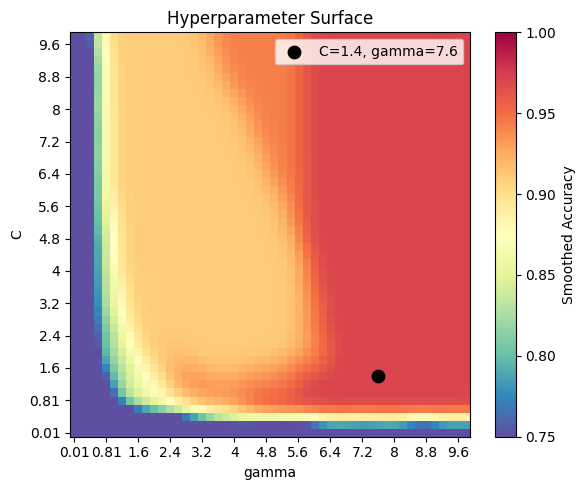

		Hyperparamters Parameters:
			C = 1.4100000000000001
			gamma = 7.61
			Validation Accuracy = 0.9714285714285718
			Validation Standard Deviation = 0.05714285714285716
		fitting final SVM model...
			Full Model Accuracy = 1.0
Extracting points from Latin Hypercube on promising side of decision boundary ...


In [ ]:
sample_size = int(2e5)
points = df_inputs.to_numpy()

if choice == 0:
    df_hull_inputs = df_inputs.copy()

elif choice == 1:
    max_idx = df['YScaled'].idxmax()
    max_point = df.loc[max_idx]

    center = max_point[input_cols].values.astype(float)

    print(f"Generating sampling {sample_size} random samples within Latin Hypercube ...")
    X = df[input_cols].to_numpy()
    lhc_samples = data_augmentation.generate_lhc(X.shape[1], n_samples=sample_size)
    df_lhc = pd.DataFrame(lhc_samples, columns=input_cols)

    lhc_points = df_lhc[input_cols].values.astype(float)

    r = 0.1
    num_points_inside = 0
    while num_points_inside < (len(input_cols)*2):
        r += 0.1
        distances = np.linalg.norm(lhc_points - center, axis=1)

        # Points inside n-dimensional sphere
        inside_mask = distances <= r
        df_hull_inputs = df_lhc[inside_mask]
        num_points_inside = len(df_hull_inputs)
        
        
else:
    print("classifying promising data points...")

    quantile = 0.75
    threshold = df["YScaled"].quantile(quantile)

    while (df["YScaled"] >= threshold).astype(int).sum() < len(input_cols) + 1:
        quantile = quantile - 0.05
        threshold = df["YScaled"].quantile(quantile)

    df["promising"] = (df["YScaled"] >= threshold).astype(int)
    print(f"\tpromising data points classified with a threshold value of {quantile}...")   

    if choice == 2:
        df_hull = df[df["promising"] == 1]
        df_hull_inputs = df_hull[input_cols]
    
    elif choice == 3:
        df_svm = df.drop(columns=["Y1", "new data point", "YScaled"])
        X = df_svm[input_cols].to_numpy()

        print(f"Generating sampling {sample_size} random samples within Latin Hypercube ...")
        lhc_samples = data_augmentation.generate_lhc(X.shape[1], n_samples=sample_size)
        df_lhc = pd.DataFrame(lhc_samples, columns=input_cols)
        
        print(f"Using SVM to define decision boundary...")
        
        df_svm = df.drop(columns=["Y1", "new data point", "YScaled"])
        df_lhc = pd.DataFrame(lhc_samples, columns=input_cols)
        
        df_modelled = data_augmentation.augment_with_svm(df_svm, df_lhc, lhc_samples, input_cols, results_dir)

        df_hull_inputs = df_modelled[input_cols]   

In [ ]:
print(f"Calaculating Convex Hull around chosen data set...")
hull, points_hull = data_augmentation.compute_convex_hull(df_hull_inputs)

print(f"Finding random sample within search space that is the furthest Euclidian distance from all input data points...")
best_point, best_dist = data_augmentation.most_isolated_point(points_hull, hull, n_samples=sample_size, seed=42)
best_point_dict = {col: val for col, val in zip(input_cols, best_point)}

Calaculating Convex Hull around chosen data set...
Finding random sample within search space that is the furthest Euclidian distance from all input data points...
	generating random seeds...
	finding internal points...
	looking for furthest points...


## Plotting

In [ ]:
new_point_flag = df["new data point"].to_numpy()

X = df_inputs.to_numpy()
Y = df_output.to_numpy()

Y = np.asarray(Y).reshape(-1, 1)

try:
    Z = df["promising"].to_numpy().reshape(-1, 1)
except:
    Z = np.zeros(len(Y)) 

In [ ]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, X, points_hull, new_point_flag, hull = hull,next_point = best_point_dict)

In [ ]:
data_plotting.domain_plot(data_folder_name, results_dir, input_cols, points, points_hull, new_point_flag, contour = Y[:, 0],next_point = best_point_dict)

In [ ]:
data_plotting.domain_io_plot(data_folder_name,results_dir,input_cols,["Y1"],X,Y,Z,next_point=best_point_dict)

## Write next point to CSV 

In [ ]:
data_loading.append_results(results_dir, data_folder_name, best_point_dict)

In [ ]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)